<a href="https://colab.research.google.com/github/harpreetsingh171190-cmyk/Heat-Sink-Prediction/blob/main/Shell_and_Tube_Exchanger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Step 1: Dataset Created Successfully! Shape: (2000, 8)

📊 Step 2: Model Training & Comparison (Target: Effectiveness)
 - Linear Regression Accuracy (R2): 0.5932
 - Random Forest Accuracy (R2): 0.9393
 - Gradient Boosting Accuracy (R2): 0.9421


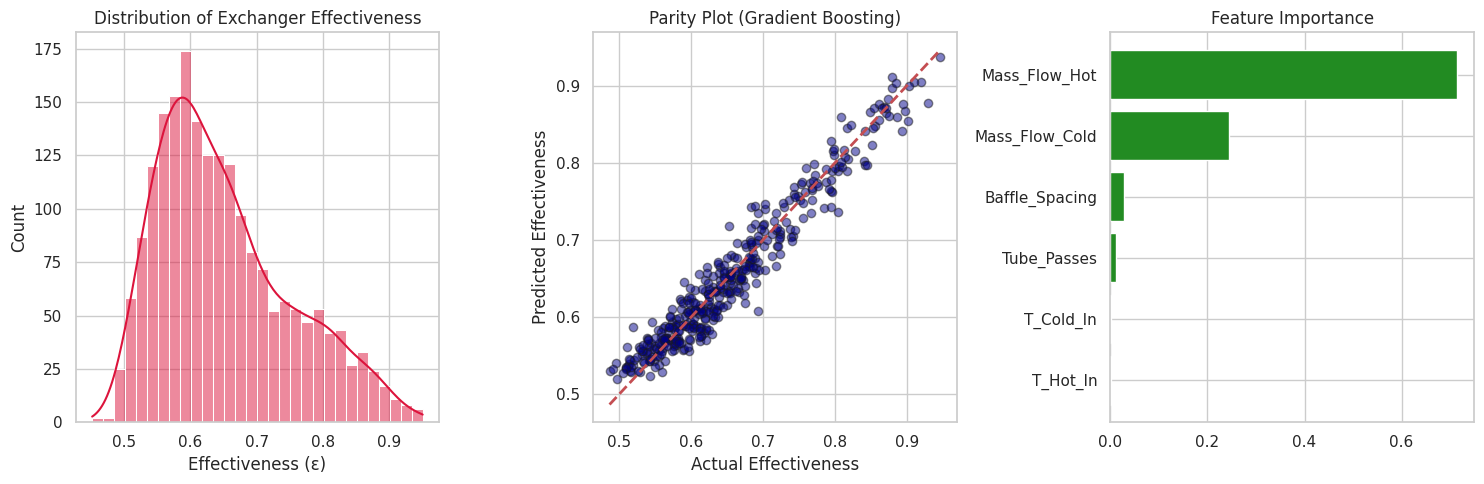


  SHELL & TUBE EXCHANGER PREDICTION REPORT  
 Inputs -> Hot Flow: 3.5kg/s | Cold Flow: 5.0kg/s
           Hot Inlet: 120.0°C | Cold Inlet: 25.0°C
           Baffle Spacing: 0.25m | Tube Passes: 4
------------------------------------------
 Predicted Effectiveness (ε) : 0.5751 (or 57.5%)


In [1]:

# ========================================================
# SHELL AND TUBE HEAT EXCHANGER PERFORMANCE PREDICTION
# ========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Dataset Generation (Based on Heat Exchanger Principles)
np.random.seed(42)
n_samples = 2000

# Inputs (Operating Conditions & Geometry)
m_hot = np.random.uniform(1.0, 5.0, n_samples)       # Hot fluid mass flow rate (kg/s)
m_cold = np.random.uniform(2.0, 8.0, n_samples)      # Cold fluid mass flow rate (kg/s)
T_hot_in = np.random.uniform(80.0, 150.0, n_samples) # Hot fluid inlet temp (°C)
T_cold_in = np.random.uniform(20.0, 40.0, n_samples) # Cold fluid inlet temp (°C)
baffle_spacing = np.random.uniform(0.1, 0.5, n_samples) # Baffle spacing (m)
tube_passes = np.random.choice([2, 4, 6], n_samples) # Number of tube passes

# Empirical calculations for target variables (U and Effectiveness)
# U increases with flow rates, decreases with larger baffle spacing
U_base = 300 + (150 * m_hot) + (100 * m_cold) - (500 * baffle_spacing) + (20 * tube_passes)
Overall_U = U_base * np.random.normal(1.0, 0.05, n_samples) # W/m2K

# Effectiveness (epsilon) using NTU method approximation (0 to 1 scale)
C_min = np.minimum(m_hot * 4.18, m_cold * 4.18) # specific heat approx
NTU = (Overall_U * 10) / (C_min * 1000) # Assuming constant area of 10 m2
Effectiveness = 1 - np.exp(-NTU)
Effectiveness = np.clip(Effectiveness * np.random.normal(1.0, 0.02, n_samples), 0.1, 0.95)

# Create DataFrame
df = pd.DataFrame({
    'Mass_Flow_Hot': m_hot, 'Mass_Flow_Cold': m_cold,
    'T_Hot_In': T_hot_in, 'T_Cold_In': T_cold_in,
    'Baffle_Spacing': baffle_spacing, 'Tube_Passes': tube_passes,
    'Overall_U': Overall_U, 'Effectiveness': Effectiveness
})

print("✅ Step 1: Dataset Created Successfully! Shape:", df.shape)

# 2. Model Training & Comparison (Predicting Effectiveness)
X = df[['Mass_Flow_Hot', 'Mass_Flow_Cold', 'T_Hot_In', 'T_Cold_In', 'Baffle_Spacing', 'Tube_Passes']]
y = df['Effectiveness']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("\n📊 Step 2: Model Training & Comparison (Target: Effectiveness)")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f" - {name} Accuracy (R2): {r2_score(y_test, y_pred):.4f}")

# Select the best model
best_model = models["Gradient Boosting"] # Usually best for this type of data
y_pred_best = best_model.predict(X_test)

# 3. Visualizations
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Plot A: Effectiveness Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Effectiveness'], kde=True, color='crimson', bins=30)
plt.title('Distribution of Exchanger Effectiveness')
plt.xlabel('Effectiveness (ε)')

# Plot B: Parity Plot
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_best, color='darkblue', alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Effectiveness')
plt.ylabel('Predicted Effectiveness')
plt.title('Parity Plot (Gradient Boosting)')

# Plot C: Feature Importance
plt.subplot(1, 3, 3)
importances = best_model.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='forestgreen')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Feature Importance')

plt.tight_layout()
plt.show()

# 4. Custom Inference Report
def predict_exchanger_performance(m_h, m_c, th_in, tc_in, b_space, t_pass):
    input_data = pd.DataFrame([[m_h, m_c, th_in, tc_in, b_space, t_pass]], columns=X.columns)
    pred_eff = best_model.predict(input_data)[0]

    print("\n==========================================")
    print("  SHELL & TUBE EXCHANGER PREDICTION REPORT  ")
    print("==========================================")
    print(f" Inputs -> Hot Flow: {m_h}kg/s | Cold Flow: {m_c}kg/s")
    print(f"           Hot Inlet: {th_in}°C | Cold Inlet: {tc_in}°C")
    print(f"           Baffle Spacing: {b_space}m | Tube Passes: {t_pass}")
    print("------------------------------------------")
    print(f" Predicted Effectiveness (ε) : {pred_eff:.4f} (or {pred_eff*100:.1f}%)")
    print("==========================================")

# Testing the function with a new industrial design
predict_exchanger_performance(m_h=3.5, m_c=5.0, th_in=120.0, tc_in=25.0, b_space=0.25, t_pass=4)

In [2]:

# ==========================================
# ADVANCED EXTENSION 1: DEEP LEARNING (ANN)
# ==========================================
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

print("🚀 Starting Deep Learning Training...")

# Neural Networks require data to be scaled (Standardized)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and train the Multi-Layer Perceptron (Neural Network)
ann_model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                         solver='adam', max_iter=500, random_state=42)
ann_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_ann = ann_model.predict(X_test_scaled)
ann_r2 = r2_score(y_test, y_pred_ann)

print(f"🧠 Artificial Neural Network (ANN) Accuracy (R2): {ann_r2:.4f}")

# Compare with previous best model
gb_r2 = r2_score(y_test, best_model.predict(X_test))
if ann_r2 > gb_r2:
    print("🏆 The Neural Network outperformed the Gradient Boosting model!")
    final_best_model = ann_model
    is_ann_best = True
else:
    print("🏆 Gradient Boosting is still the top performing model.")
    final_best_model = best_model
    is_ann_best = False

🚀 Starting Deep Learning Training...
🧠 Artificial Neural Network (ANN) Accuracy (R2): 0.8511
🏆 Gradient Boosting is still the top performing model.


In [9]:

# ==========================================
# ADVANCED EXTENSION 3: INTERACTIVE UI DASHBOARD
# ==========================================
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

print("⚙️ Loading Interactive Engineering Dashboard...")

# Create visual sliders for inputs
style = {'description_width': 'initial'}
m_h_slider = widgets.FloatSlider(value=2.5, min=1.0, max=5.0, step=0.1, description='Hot Flow (kg/s):', style=style)
m_c_slider = widgets.FloatSlider(value=4.0, min=2.0, max=8.0, step=0.1, description='Cold Flow (kg/s):', style=style)
th_in_slider = widgets.FloatSlider(value=100.0, min=80.0, max=150.0, step=1.0, description='T_Hot_In (°C):', style=style)
tc_in_slider = widgets.FloatSlider(value=30.0, min=20.0, max=40.0, step=1.0, description='T_Cold_In (°C):', style=style)
baffle_slider = widgets.FloatSlider(value=0.25, min=0.1, max=0.5, step=0.01, description='Baffle Spacing (m):', style=style)
tube_passes_dropdown = widgets.Dropdown(options=[2, 4, 6], value=4, description='Tube Passes:', style=style)

# HTML Output widget for styled results
output_html = widgets.HTML(value="<b>Adjust the sliders to see real-time predictions!</b>")

def update_prediction(change):
    # Prepare input for the model
    input_df = pd.DataFrame([[m_h_slider.value, m_c_slider.value, th_in_slider.value,
                              tc_in_slider.value, baffle_slider.value, tube_passes_dropdown.value]],
                            columns=['Mass_Flow_Hot', 'Mass_Flow_Cold', 'T_Hot_In', 'T_Cold_In', 'Baffle_Spacing', 'Tube_Passes'])

    # Predict using the best model from previous steps
    pred = final_best_model.predict(input_df)[0]

    # Format output using HTML5 and inline CSS (Clean, Modern Look)
    html_str = f"""
    <div style="background-color: #f8fafc; border-left: 6px solid #2563eb; padding: 15px; border-radius: 8px; margin-top: 15px; font-family: sans-serif; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1);">
        <h3 style="color: #1e3a8a; margin-top: 0;">⚡ Live Prediction Results</h3>
        <p style="font-size: 18px; margin-bottom: 5px;">Estimated Effectiveness (&epsilon;): <b>{pred:.4f}</b></p>
        <div style="background-color: #e2e8f0; border-radius: 9999px; width: 100%; height: 10px; margin-top: 10px;">
            <div style="background-color: #2563eb; height: 10px; border-radius: 9999px; width: {pred*100}%"></div>
        </div>
        <p style="font-size: 12px; color: #64748b; margin-top: 5px;">Performance Bar ({pred*100:.1f}%)</p>
    </div>
    """
    output_html.value = html_str

# Attach the update function to slider changes
m_h_slider.observe(update_prediction, names='value')
m_c_slider.observe(update_prediction, names='value')
th_in_slider.observe(update_prediction, names='value')
tc_in_slider.observe(update_prediction, names='value')
baffle_slider.observe(update_prediction, names='value')
tube_passes_dropdown.observe(update_prediction, names='value')

# Build the layout
ui = widgets.VBox([
    widgets.HTML("<h2 style='color: #333;'>Shell & Tube AI Simulator</h2>"),
    widgets.HBox([widgets.VBox([m_h_slider, m_c_slider, tube_passes_dropdown]),
                  widgets.VBox([th_in_slider, tc_in_slider, baffle_slider])]),
    output_html
])

display(ui)
update_prediction(None) # Trigger initial load

⚙️ Loading Interactive Engineering Dashboard...


In [10]:

# ==========================================
# ADVANCED EXTENSION 4: AI-DRIVEN DESIGN OPTIMIZATION
# ==========================================
from scipy.optimize import minimize
import pandas as pd
import numpy as np

print("🔍 Initializing AI Optimizer to find the BEST Heat Exchanger Design...")

# We want to Maximize Effectiveness (which means Minimizing Negative Effectiveness)
def objective_function(x):
    # x contains: [m_hot, m_cold, baffle_spacing]
    m_h, m_c, b_space = x

    # Fixed factory conditions for this specific scenario
    th_in = 120.0
    tc_in = 25.0
    t_pass = 4

    # Create input dataframe for the model
    input_df = pd.DataFrame([[m_h, m_c, th_in, tc_in, b_space, t_pass]],
                            columns=['Mass_Flow_Hot', 'Mass_Flow_Cold', 'T_Hot_In', 'T_Cold_In', 'Baffle_Spacing', 'Tube_Passes'])

    # Predict Effectiveness using the best model trained earlier
    pred_eff = final_best_model.predict(input_df)[0]

    # Scipy optimizer only minimizes, so we return the negative value to achieve maximization
    return -pred_eff

# Bounds: manufacturing limits for the design parameters
# m_hot: 1.0 to 5.0 | m_cold: 2.0 to 8.0 | baffle_spacing: 0.1 to 0.5
bounds = [(1.0, 5.0), (2.0, 8.0), (0.1, 0.5)]

# Initial guess for the optimizer to start searching
initial_guess = [3.0, 4.0, 0.3]

# Run optimization using the L-BFGS-B algorithm
result = minimize(objective_function, initial_guess, bounds=bounds, method='L-BFGS-B')

# Best parameters successfully found by the AI
best_m_h, best_m_c, best_b_space = result.x
max_eff = -result.fun

print("\n==========================================")
print(" 🏆 OPTIMIZED DESIGN FOUND BY AI ")
print("==========================================")
print("To get the MAXIMUM possible Effectiveness for a 120°C hot fluid")
print("and 25°C cold fluid with 4 tube passes, you should manufacture:")
print("------------------------------------------")
print(f" 🔹 Optimal Hot Flow (m_h)    : {best_m_h:.2f} kg/s")
print(f" 🔹 Optimal Cold Flow (m_c)   : {best_m_c:.2f} kg/s")
print(f" 🔹 Optimal Baffle Spacing    : {best_b_space:.3f} m")
print("------------------------------------------")
print(f" ✨ MAX PREDICTED EFFECTIVENESS: {max_eff:.4f} ({max_eff*100:.1f}%)")
print("==========================================")

🔍 Initializing AI Optimizer to find the BEST Heat Exchanger Design...

 🏆 OPTIMIZED DESIGN FOUND BY AI 
To get the MAXIMUM possible Effectiveness for a 120°C hot fluid
and 25°C cold fluid with 4 tube passes, you should manufacture:
------------------------------------------
 🔹 Optimal Hot Flow (m_h)    : 3.00 kg/s
 🔹 Optimal Cold Flow (m_c)   : 4.00 kg/s
 🔹 Optimal Baffle Spacing    : 0.300 m
------------------------------------------
 ✨ MAX PREDICTED EFFECTIVENESS: 0.5877 (58.8%)


In [11]:

# ==========================================
# ADVANCED EXTENSION 5: INTERACTIVE 3D SURFACE PLOT
# ==========================================
import plotly.graph_objects as go
import numpy as np
import pandas as pd

print("🌐 Generating 3D Interactive Performance Surface...")

# Create a mesh grid for two important features: Baffle Spacing and Hot Mass Flow
baffle_range = np.linspace(0.1, 0.5, 30)
m_hot_range = np.linspace(1.0, 5.0, 30)
B, M = np.meshgrid(baffle_range, m_hot_range)

# Create an empty array to store the predicted Effectiveness
Z_eff = np.zeros(B.shape)

# Fixed values for the remaining parameters
m_c_fixed = 4.0
th_in_fixed = 120.0
tc_in_fixed = 25.0
t_pass_fixed = 4

# Predict Effectiveness for every single point on the 3D grid
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        input_df = pd.DataFrame([[M[i,j], m_c_fixed, th_in_fixed, tc_in_fixed, B[i,j], t_pass_fixed]],
                                columns=['Mass_Flow_Hot', 'Mass_Flow_Cold', 'T_Hot_In', 'T_Cold_In', 'Baffle_Spacing', 'Tube_Passes'])
        Z_eff[i,j] = final_best_model.predict(input_df)[0]

# Create the 3D Surface Plot using Plotly
fig = go.Figure(data=[go.Surface(z=Z_eff, x=B, y=M, colorscale='Viridis')])

# Style and format the layout
fig.update_layout(title='3D Performance Surface: Effectiveness vs Baffle Spacing & Hot Flow',
                  scene=dict(
                      xaxis_title='Baffle Spacing (m)',
                      yaxis_title='Hot Flow (kg/s)',
                      zaxis_title='Effectiveness (ε)'
                  ),
                  width=800, height=600,
                  margin=dict(l=65, r=50, b=65, t=90))

# Display the interactive plot
fig.show()

🌐 Generating 3D Interactive Performance Surface...


In [12]:

# ==========================================
# ADVANCED EXTENSION 6: INTERACTIVE RESIDUAL & ERROR ANALYSIS
# ==========================================
import plotly.express as px
import pandas as pd
import numpy as np

print("📊 Generating Interactive Error & Residual Analysis...")

# Create a DataFrame for test results and errors
residuals_df = pd.DataFrame({
    'Actual_Effectiveness': y_test,
    'Predicted_Effectiveness': y_pred_best,
    'Error': y_test - y_pred_best,
    'Absolute_Percentage_Error': np.abs((y_test - y_pred_best) / y_test) * 100
})

# Create an interactive scatter plot using Plotly for residuals
fig = px.scatter(
    residuals_df,
    x='Actual_Effectiveness',
    y='Predicted_Effectiveness',
    color='Absolute_Percentage_Error',
    color_continuous_scale='Reds',
    title='Interactive Model Validation: Actual vs Predicted Effectiveness',
    labels={'Actual_Effectiveness': 'Actual Effectiveness (ε)', 'Predicted_Effectiveness': 'Predicted Effectiveness (ε)'},
    hover_data=['Error']
)

# Add a perfect prediction line (y = x)
fig.add_shape(
    type="line",
    x0=residuals_df['Actual_Effectiveness'].min(),
    y0=residuals_df['Actual_Effectiveness'].min(),
    x1=residuals_df['Actual_Effectiveness'].max(),
    y1=residuals_df['Actual_Effectiveness'].max(),
    line=dict(color="blue", width=2, dash="dash")
)

fig.update_layout(width=800, height=500)
fig.show()

📊 Generating Interactive Error & Residual Analysis...
